In [1]:
# To import the relevant libraries
import pandas as pd
import matplotlib.pyplot as plt

#!pip install mlxtend
import mlxtend
from mlxtend.frequent_patterns import apriori, association_rules

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
print(pd.__version__)
print(mlxtend.__version__)

2.3.3
0.23.4


In [4]:
df = pd.read_csv('/Users/calvin/Library/CloudStorage/Dropbox/SUSS/sem 6/Association and Clustering/ANL305_Datasets/ElectroMart.csv')
print(df.shape)
df.head(10)
#df[['Gender', 'Home Type']].head(10)

(786, 15)


,Speakers,DVD Player,Camcorders,MP3 Player,LCD TV,Home Theatre System,GPS,Camera,Playstation,Amplifiers,Gender,Age,Home Type,Member,Spending
0,1,0,1,0,0,1,0,0,0,0,Male,12 to 21,LH Landed,No,1363
1,1,0,0,0,0,0,0,0,1,0,Female,32 to 41,LH Landed,Yes,764
2,0,0,0,0,0,0,0,0,0,1,Female,42 to 51,FH Landed,Yes,2657
3,1,0,0,0,0,0,0,1,1,0,Male,12 to 21,LH Condo,No,597
4,0,0,1,0,0,0,0,0,0,0,Male,12 to 21,LH Condo,No,1203
5,0,1,1,0,0,0,0,0,0,0,Male,12 to 21,LH Condo,No,932
6,0,1,0,0,1,1,0,0,1,0,Male,12 to 21,LH Condo,No,1389
7,1,0,0,0,0,1,0,0,0,0,Female,32 to 41,FH Landed,No,1361
8,1,0,0,0,0,0,0,0,0,0,Male,12 to 21,LH Condo,Yes,787
9,0,1,0,0,0,0,0,1,0,1,Male,42 to 51,HDB,No,921


In [5]:
# -----------------------------
# Equal-Width (EW) binning
# -----------------------------
df["Spending_EW"] = pd.cut(
    df["Spending"],
    bins=4,
    labels=["Low", "Medium", "High", "Very High"]
)

# -----------------------------
# Equal-Frequency (EF) binning
# -----------------------------
df["Spending_EF"] = pd.qcut(
    df["Spending"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

df.head()

,Speakers,DVD Player,Camcorders,MP3 Player,LCD TV,Home Theatre System,GPS,Camera,Playstation,Amplifiers,Gender,Age,Home Type,Member,Spending,Spending_EW,Spending_EF
0,1,0,1,0,0,1,0,0,0,0,Male,12 to 21,LH Landed,No,1363,Medium,High
1,1,0,0,0,0,0,0,0,1,0,Female,32 to 41,LH Landed,Yes,764,Low,Medium
2,0,0,0,0,0,0,0,0,0,1,Female,42 to 51,FH Landed,Yes,2657,Very High,Very High
3,1,0,0,0,0,0,0,1,1,0,Male,12 to 21,LH Condo,No,597,Low,Low
4,0,0,1,0,0,0,0,0,0,0,Male,12 to 21,LH Condo,No,1203,Medium,High


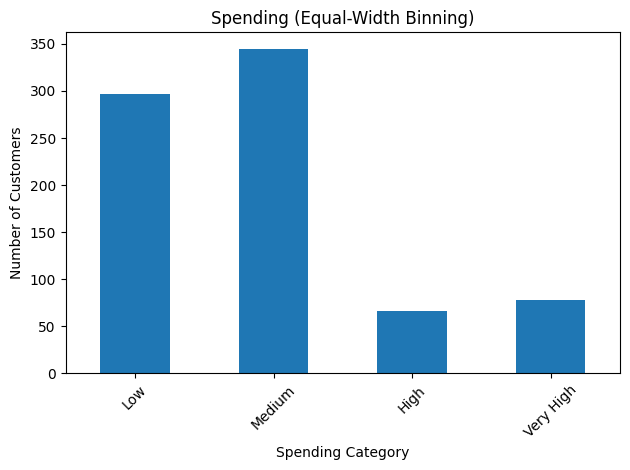

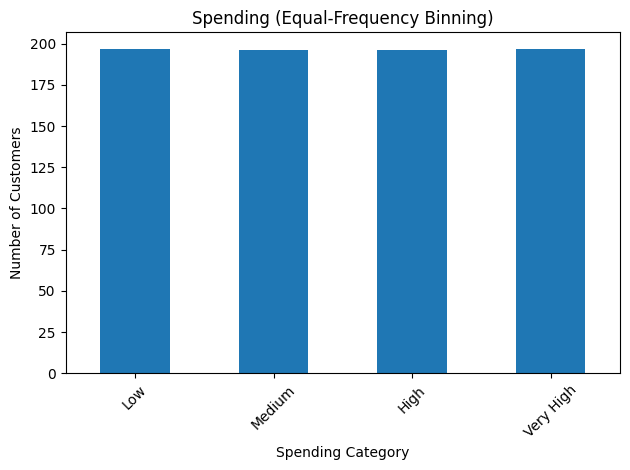

In [6]:
# -----------------------------
# Histogram: Equal-Width (EW)
# -----------------------------
plt.figure()
df["Spending_EW"].value_counts().sort_index().plot(kind="bar")
plt.title("Spending (Equal-Width Binning)")
plt.xlabel("Spending Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# Histogram: Equal-Frequency (EF)
# -----------------------------
plt.figure()
df["Spending_EF"].value_counts().sort_index().plot(kind="bar")
plt.title("Spending (Equal-Frequency Binning)")
plt.xlabel("Spending Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# ------------------------------------------
# Data transformation: categorical to binary
# ------------------------------------------

demo_cols = ["Gender", "Age", "Home Type", "Member", "Spending_EW"]

X_demo = pd.get_dummies(df[demo_cols],
                        prefix_sep="_").astype(int)
X_demo.head(10)

,Gender_Female,Gender_Male,Age_12 to 21,Age_22 to 31,Age_32 to 41,Age_42 to 51,Age_Over 52,Home Type_FH Condo,Home Type_FH Landed,Home Type_HDB,Home Type_LH Condo,Home Type_LH Landed,Member_No,Member_Yes,Spending_EW_Low,Spending_EW_Medium,Spending_EW_High,Spending_EW_Very High
0,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0
1,1,0,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0
2,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1
3,0,1,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0
4,0,1,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0
5,0,1,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0
6,0,1,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0
7,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0
8,0,1,1,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0
9,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0


In [8]:
#Merge the purchase columns with transformed demo columns

cols_to_analyze = pd.concat([df.iloc[:, 0:10].reset_index(drop=True),
                             X_demo.reset_index(drop=True)],
                            axis=1)

#Find frequent itemsets with minimum support in 10% (min_support)

frequent_itemsets = apriori(cols_to_analyze, min_support = 0.1,
                            max_len = 4, use_colnames = True)

#Generate association rules using confidence
rules = association_rules(frequent_itemsets,
                          metric = "confidence",
                          min_threshold = 0.6).sort_values(by='confidence',
                                                           ascending=False)
print(len(rules))
rules.head(10)


233


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
106,"(Spending_EW_Low, Camcorders)",(Member_No),0.166667,0.652672,0.159033,0.954198,1.461988,1.0,0.050254,7.583333,0.379200,0.240848,0.868132,0.598932
219,"(DVD Player, Gender_Male, Spending_EW_Medium)",(Member_No),0.106870,0.652672,0.101781,0.952381,1.459204,1.0,0.032030,7.293893,0.352350,0.154739,0.862899,0.554163
213,"(DVD Player, Spending_EW_Medium, Camcorders)",(Member_No),0.111959,0.652672,0.105598,0.943182,1.445109,1.0,0.032525,6.112977,0.346843,0.160232,0.836414,0.552488
198,"(Gender_Male, Speakers, Spending_EW_Low)",(Member_No),0.109415,0.652672,0.101781,0.930233,1.425269,1.0,0.030369,4.978372,0.335036,0.154143,0.799131,0.543089
228,"(Age_12 to 21, Gender_Male, Home Type_LH Condo)",(Member_No),0.108142,0.652672,0.100509,0.929412,1.424011,1.0,0.029927,4.920483,0.333863,0.152216,0.796768,0.541704
210,"(DVD Player, Gender_Male, Camcorders)",(Member_No),0.123410,0.652672,0.114504,0.927835,1.421595,1.0,0.033958,4.812977,0.338316,0.173077,0.792228,0.551637
225,"(Gender_Male, Spending_EW_Medium, Camcorders)",(Member_No),0.118321,0.652672,0.109415,0.924731,1.416840,1.0,0.032190,4.614504,0.333686,0.165385,0.783292,0.546186
196,"(Playstation, Speakers, Spending_EW_Low)",(Member_No),0.117048,0.652672,0.108142,0.923913,1.415586,1.0,0.031748,4.564885,0.332497,0.163462,0.780936,0.544803
136,"(Age_12 to 21, Gender_Male)",(Member_No),0.161578,0.652672,0.148855,0.921260,1.411521,1.0,0.043398,4.411069,0.347730,0.223709,0.773298,0.574665
68,"(Speakers, Spending_EW_Low)",(Member_No),0.220102,0.652672,0.201018,0.913295,1.399317,1.0,0.057364,4.005852,0.365901,0.299242,0.750365,0.610644
